In [1]:
from attention_motifs.dataset.dataset import (
	APGenerationConfig,
	PromptDatasetConfig,
	CollectedAttentionPatternDataloader,
)

In [2]:
# magic autoreload
%load_ext autoreload
%autoreload 2

In [3]:
d = CollectedAttentionPatternDataloader.generate(
	config=APGenerationConfig(
		prompts_config=PromptDatasetConfig.from_source_path("../data/pile_5.jsonl"),
		model_names=[
			"meta-llama/Llama-3.2-1B",
			# "gpt2-small",
			# "pythia-14m",
		],
	),
	max_batch_size=8,
)

# Processing model: meta-llama/Llama-3.2-1B
--------------------------------------------------
| (5.14s) Loading model meta-llama/Llama-3.2-1B                                

\ (14.60s) Loading model meta-llama/Llama-3.2-1B                               Loaded pretrained model meta-llama/Llama-3.2-1B into HookedTransformer
# (14.65s) Loading model meta-llama/Llama-3.2-1B                               
#	loaded meta-llama/Llama-3.2-1B with 1073741824 (1.1B) parameters
#	model devices: {device(type='cuda', index=0)}
# (0.18s) tokenizing and binning prompts                                       
#	shapes of each bin contents (n_seqs, n_ctx): [ (19, 192), (1, 64), (1, 128) ]
# getting attention patterns:


n_ctx = 192:   0%|          | 0.00/21.0 [00:00<?, ?Seq/s]

Processing batch idx_start=0, idx_end=8
tokens_batch.shape=torch.Size([8, 192])
	forwards done
Processing batch idx_start=8, idx_end=16
tokens_batch.shape=torch.Size([8, 192])
	forwards done
Processing batch idx_start=16, idx_end=19
tokens_batch.shape=torch.Size([3, 192])
	forwards done


n_ctx = 64:  90%|█████████ | 19.0/21.0 [01:14<00:07, 3.91s/Seq] 

...

n_ctx = 128:  95%|█████████▌| 20.0/21.0 [01:15<00:03, 3.71s/Seq]

Processing batch idx_start=0, idx_end=1
tokens_batch.shape=torch.Size([1, 128])
	forwards done


n_ctx = 128: 100%|██████████| 21.0/21.0 [01:17<00:00, 3.70s/Seq]

/ (0.10s) assembling datasets                                                  

# (0.69s) assembling datasets                                                  
# done generating datasets! summary:
--------------------------------------------------
{
  "n_total_samples": 10752,
  "n_prompts": 23,
  "n_datasets": 3,
  "config": {
    "prompts_config": {
      "name": "pile_5",
      "source_path": "../data/pile_5.jsonl",
      "char_len_min": 64,
      "char_len_max": 1024
    },
    "model_names": [
      "meta-llama/Llama-3.2-1B"
    ],
    "token_len_min": 64,
    "prompt_token_len_tolerance": 64,
    "raw_scores": false
  },
  "dataset_shapes_summary": [
    "(9728, 192, 192)",
    "(512, 64, 64)",
    "(512, 128, 128)"
  ]
}
--------------------------------------------------


In [4]:
d.save("../data/activations/pile_1k-llama", verbose=True)

# (0.22s) Saving metadata                                                      
# (0.06s) Saving prompts                                                       


Saving datasets: 100%|██████████| 3/3 [00:19<00:00,  6.58s/dataset]


torch.Size([2, 192, 192])
[AttentionPatternMetadata(model_name='meta-llama/Llama-3.2-1B', idx_layer=0, idx_head=0, n_ctx=192, prompt_hash=10697441533221209697), AttentionPatternMetadata(model_name='meta-llama/Llama-3.2-1B', idx_layer=0, idx_head=0, n_ctx=192, prompt_hash=8212905469003103652)]


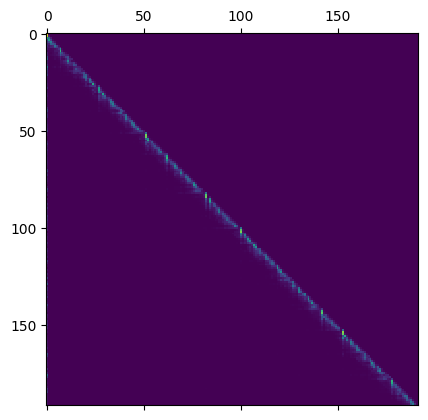

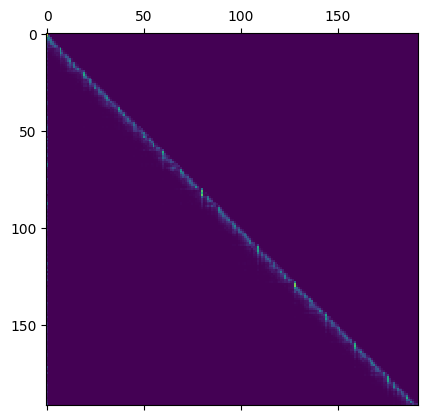

In [5]:
import matplotlib.pyplot as plt

for x in d.batches(2):
	print(x[0].shape)
	print(x[1])
	plt.matshow(x[0][0].cpu().numpy())
	plt.show()
	plt.matshow(x[0][1].cpu().numpy())
	plt.show()
	break